In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *
import matplotlib.pyplot as plt

## SANTIMENT SOCIAL METRICS FOR A SELECTED GROUP OF WORDS
- O Google Trends não fornece o número absoluto de buscas, mas sim um índice de interesse normalizado.O valor $100$ representa o pico de popularidade do termo no período e local selecionados. Um valor de $50$ significa que o termo teve metade da popularidade daquele pico.

- Fonte1: https://academy.santiment.net/metrics/social-dominance/
- Fonte2: https://academy.santiment.net/metrics/social-volume/#definition

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
A Economia da Atenção (Hype-Driven Price). Num mercado ineficiente e movido por investidores individuais, a "atenção" funcionava como a principal proxy de demanda. Hipotetiza-se uma correlação linear positiva entre o volume social e o preço.

Se o Social Spread aumentava (mais discussões sobre Bitcoin), isso traduzia-se imediatamente em pressão de compra por FOMO (Fear Of Missing Out). O "burburinho" nas redes sociais causava a alta do preço de forma direta.

## Hipótese 2: Era Institucional (Pós-2020)
Sinal "Contrarian" e Liquidez de Saída. Investidores institucionais não tomam decisões de alocação baseados em trends do Twitter, mas monitoram o sentimento do varejo para identificar extremos de euforia ou pânico. Hipotetiza-se que a métrica social tornou-se um Indicador Contrário.

Picos de Euforia Social: Geralmente coincidem com topos locais de preço. O "Smart Money" utiliza a entrada massiva do varejo (sinalizada pelo volume social alto) como liquidez de saída para realizar lucros (Venda).

Depressão Social: Baixo volume social indica capitulação do varejo, sendo interpretado por instituições como zonas de acumulação de valor (Compra). Portanto, a relação deixa de ser linear e passa a ser inversa nos extremos.

### TRATAMENTO
- O Spread Negativo (Média -5.87): Como somou-se o volume de todas as Altcoins (ETH + SOL + ADA + "Altcoin Season"...), o volume agregado delas será sempre maior que o do Bitcoin sozinho. O que importa para o modelo não é o sinal negativo, mas a variação (se for de -5 para -3, o BTC ganhou força relativa).

O Z-Score (Total Market Noise):Isso permite que o modelo saiba a diferença entre "Mercado em Silêncio" (Z < -1) e "Euforia Generalizada" (Z > 2). O Bitcoin se comporta de forma diferente nesses dois regimes.

Tratamento de Zeros: O uso de np.log1p (log de x+1) é a prática correta para evitar erros matemáticos em dias de volume zero.

In [28]:
df_social = pd.read_csv(rf"raw/2012_btc_altcoin_social_metrics.csv")
df_social['Data_UTC'] = pd.to_datetime(df_social['Date'], utc=True).dt.strftime("%Y-%m-%d")

df_social = df_social.rename(columns={'BTC / USD':'btc_price',
                                  'Social Volume (btc OR bitcoin)':'btc_social_volume',
                                  'Social Dominance (btc OR bitcoin)':'btc_social_dominance',
                                  'Social Volume (altcoin OR altcoins OR "altcoin season" OR "altcoin pump" OR "altcoin rally")':'alt_social_volume',
                                  'Social Dominance (altcoin OR altcoins OR "altcoin season" OR "altcoin pump" OR "altcoin rally")':'alt_social_dominance',
                                  'Social Volume (ethereum OR eth OR solana OR sol OR cardano OR ada OR polkadot OR dot OR ripple OR xrp OR dogecoin OR doge OR memecoin OR shiba)':'alt_social_volume_2',
                                  'Social Dominance (ethereum OR eth OR solana OR sol OR cardano OR ada OR polkadot OR dot OR ripple OR xrp OR dogecoin OR doge OR memecoin OR shiba)':'alt_social_dominance_2',
                                  })

df_social['Data_UTC'] = pd.to_datetime(df_social['Data_UTC'], utc=True,).dt.strftime("%Y-%m-%d")

df_social

df_social_tratado = (
    df_periodo
        .merge(df_social, how='left', on='Data_UTC')
        .sort_values('Data_UTC')
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        
        # 1. Tratamento de Volume (Escala Logarítmica para normalizar contagem)
        .assign(btc_log_vol = lambda df: np.log1p(df['btc_social_volume']))
        .assign(alt_total_log_vol = lambda df: np.log1p(df['alt_social_volume'] + df['alt_social_volume_2']))
        
        # 4. Intensidade do Barulho (Z-Score ou Spread de Volume)
        # Indica se o mercado está em um momento de alta atividade (Hype)
        .assign(social_vol_spread = lambda df: df['btc_log_vol'] - df['alt_total_log_vol'])
        
        # 5. Momentum e Aceleração (Derivadas para Séries Temporais)
        # Útil para modelos de Causalidade de Granger ou Regressões Dinâmicas
        .assign(vol_acceleration = lambda df: df['social_vol_spread'].diff())

        .assign(social_vol_spread_ma7 = lambda df: df['social_vol_spread'].rolling(window=7).mean())

        .fillna(0)

        # Seleção das colunas chave para o modelo de Data Science
        [[
            'Data_UTC',
            'btc_social_volume',
            'btc_log_vol',
            'alt_total_log_vol',
            'social_vol_spread',       # Intensidade relativa (Volume)
            'vol_acceleration'         # Explosão de interesse
        ]]
)

df_social_tratado

# print_dataframe_info(df_social_tratado, "Social Metrics ")

,Data_UTC,btc_social_volume,btc_log_vol,alt_total_log_vol,social_vol_spread,vol_acceleration
0,2016-12-31,1862,7.529943,6.248043,1.281900,0.000000
1,2017-01-01,2010,7.606387,6.354370,1.252017,-0.029883
2,2017-01-02,3073,8.030735,6.599870,1.430864,0.178847
3,2017-01-03,3117,8.044947,6.869014,1.175933,-0.254932
4,2017-01-04,3987,8.291045,6.977281,1.313764,0.137831
...,...,...,...,...,...,...
3131,2025-07-28,5396,8.593599,8.643826,-0.050227,-0.142601
3132,2025-07-29,5096,8.536407,8.517593,0.018814,0.069042
3133,2025-07-30,5144,8.545781,8.525756,0.020024,0.001210
3134,2025-07-31,4839,8.484670,8.328209,0.156461,0.136436


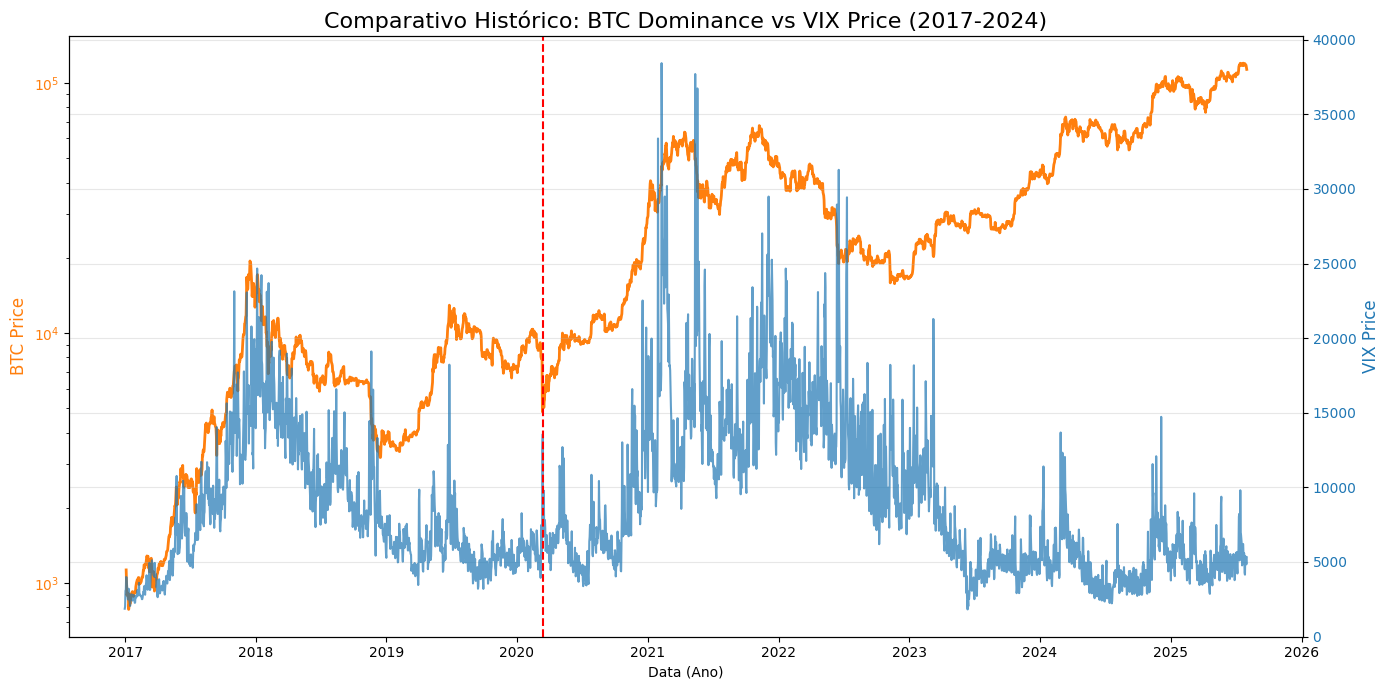

In [27]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_features_crua['Data_UTC'], df_features_crua['btc_price_close'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('VIX Price', color=color, fontsize=12)
ax2.plot(df_social_tratado['Data_UTC'], df_social_tratado['btc_social_volume'], color=color, label='VIX', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs VIX Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()